<a href="https://colab.research.google.com/github/iprachuk/internet_shop_sales_analysis/blob/main/internet_shop_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")
#sql-request to bigquery
query = """
SELECT
CASE when ord.ga_session_id IS NOT NULL THEN s.date ELSE NULL END as order_date,
s.ga_session_id as session_identificator,
sp.continent,
sp.country,
sp.device,
sp.mobile_model_name,
sp.operating_system,
sp.language,
sp.medium as  source_of_traffic,
sp.name as name_of_traffic,
sp.channel,
ac.id as identificator_account,
ac.is_verified as email_verified,
ac.is_unsubscribed as email_unsubscribed,
pr.category,
pr.name as name_product,
pr.price,
pr.short_description
FROM `data-analytics-mate.DA.session` AS s
LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS ac
  ON acs.account_id = ac.id
LEFT JOIN `data-analytics-mate.DA.order` AS ord
  ON s.ga_session_id = ord.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS pr
  ON ord.item_id = pr.item_id
"""

query_job = client.query(query)

df = query_job.to_dataframe(create_bqstorage_client=False)

df.head()

#download file
df.to_csv('/content/drive/MyDrive/Mate/Collaborative/Files/internet_shop_sales.csv', index = False)


Mounted at /content/drive


## **Dataset Description**

### **- Total number of columns**

> Count columns: 18

### **- Number of numeric columns (and which ones)**

> Counting numeric columns and listing them: 5

1. session_identificator
2. identificator_account
3. email_verified
4. email_unsubscribed
5. price

### **- Number of categorical columns (and which ones)**

> **Counting object columns: 12**

1. continent
2. country
3. device
4. mobile_model_name
5. operating_system
6. language
7. source_of_traffic
8. name_of_traffic
9. channel
10. category
11. name_product
12. short_description

### **- Number of datetime columns**

> **Counting object columns: 1**

1. order_date

### **- Number of unique sessions**

> **count of unique session: 349545**

### **- Time period covered (from… to…)**
> Date from 2020-11-01 00:00:00 to 2021-01-27 00:00:00

### **- Are there missing values?**
> Yes, we have empty values

### **- Which columns have more missing values and why?**
> The highest number of missing values expressed as a percentage:
- order_date: 90.4%
- identificator_account: 92.0%
- email_verified: 92.0%
- email_unsubscribed: 92.0%
- category: 90.4%
- name_product: 90.4%
- price: 90.4%
- short_description: 90.4%

Our main goal was to ensure all sessions were accessible, even if no orders were placed. This explains the many empty values in order_date, id_account, and other columns linked to orders and registered accounts. The absence of 'language' might be due to ad blockers or privacy restrictions.

### **- Are there duplicate rows?**
> Count of duplicate values: 0

### **- Unique values in key categories (countries, continents, devices, channels)**
> Count of unique country names: 108

> Count of unique continent names: 6

> Count of unique channel names: 5

> Count of unique device names: 3

### **- Data distribution by main categories (device, continent, channel, category)**

#### **> Distribution by device**
Our distribution by device is uneven; most traffic is focused on mobile and desktop users.

In [3]:
#Function to count the number of columns by type
def count_columns(df, column_type):
  type_columns = df.select_dtypes(include= column_type).columns
  return len(type_columns), list(type_columns)

#overall count of columns
print(f"Count columns: {df.shape[1]}")
print("-------------------------------------------------------------------------------")
#count numeric of columns
print(f"Counting numeric columns and list with their: {count_columns(df,['number'])}")
print("-------------------------------------------------------------------------------")
#count categorical of columns
print(f"Counting object columns and list with their: {count_columns(df,['object'])}")
print("-------------------------------------------------------------------------------")
#count date of columns
print(f"Counting datetime columns and list with their: {count_columns(df,['datetime', 'dbdate'])}")
print("-------------------------------------------------------------------------------")
#count unique session
count_unique_sessions = df['session_identificator'].nunique()
print(f"count of unique session: {count_unique_sessions}")
print("-------------------------------------------------------------------------------")
#Min and max date
min_date = df['order_date'].min()
max_date = df['order_date'].max()
print(f'Date from {min_date} to {max_date}')
print("-------------------------------------------------------------------------------")
#missed values
print(f"Number of empty values:\n {df.isna().sum()}")
print("-------------------------------------------------------------------------------")
print(f'Percent by columns:\n {df.isna().sum() / df.shape[0] * 100}')
print("-------------------------------------------------------------------------------")
#duplicated values
print(f"Count of duplicate values: {df.duplicated().sum()}")
print("-------------------------------------------------------------------------------")
#unique values in categories
print(f"Count of unique countries name: {df['country'].nunique()}")
print(f"Count of unique continents name: {df['continent'].nunique()}")
print(f"Count of unique channels name: {df['channel'].nunique()}")
print(f"Count of unique device name: {df['device'].nunique()}")
print("-------------------------------------------------------------------------------")
#distribution session by categories: 'device','continent', 'channel', 'category'
distribution_of_session_by_device = df.groupby('device').agg(count_of_session = ('session_identificator', 'nunique'), count_of_account = ("identificator_account", 'nunique')).sort_values(by="count_of_session", ascending = False)
print(distribution_of_session_by_device)
print("-------------------------------------------------------------------------------")
distribution_of_session_by_continent = df.groupby('continent').agg(count_of_session = ('session_identificator', 'nunique'), count_of_account = ("identificator_account", 'nunique')).sort_values(by="count_of_session", ascending = False)
print(distribution_of_session_by_continent)
print("-------------------------------------------------------------------------------")
distribution_of_session_by_channel = df.groupby('channel').agg(count_of_session = ('session_identificator', 'nunique'), count_of_account = ("identificator_account", 'nunique')).sort_values(by="count_of_session", ascending = False)
print(distribution_of_session_by_channel)
print("-------------------------------------------------------------------------------")
distribution_of_session_by_category = df.groupby('category').agg(count_of_session = ('session_identificator', 'nunique'), count_of_account = ("identificator_account", 'nunique')).sort_values(by="count_of_session", ascending = False)
print(distribution_of_session_by_category)

Count columns: 18
-------------------------------------------------------------------------------
Counting numeric columns and list with their: (5, ['session_identificator', 'identificator_account', 'email_verified', 'email_unsubscribed', 'price'])
-------------------------------------------------------------------------------
Counting object columns and list with their: (12, ['continent', 'country', 'device', 'mobile_model_name', 'operating_system', 'language', 'source_of_traffic', 'name_of_traffic', 'channel', 'category', 'name_product', 'short_description'])
-------------------------------------------------------------------------------
Counting datetime columns and list with their: (1, ['order_date'])
-------------------------------------------------------------------------------
count of unique session: 349545
-------------------------------------------------------------------------------
Date from 2020-11-01 to 2021-01-27
----------------------------------------------------------

### **- Which continents (Top-3) and countries (Top-5) have the highest sales and order counts?**

Top-3 continents by sales:
1. Americas: 17,665,280.0
2. Asia: 7,601,298.3
3. Europe: 5,934,624.2

Top-5 countries by sales:
1. United States: 13,943,553.9
2. India: 2,809,762.0
3. Canada: 2,437,921.0
4. United Kingdom: 938,317.9
5. France: 710,692.8

In [4]:
#top-3 continent, top-5 country by sales, count of orders
top_continent_by_sales = df.groupby("continent").agg(sales = ('price', 'sum')).reset_index().sort_values(by = 'sales',ascending = False)
print(top_continent_by_sales.head(3))
print("-------------------------------------------------------------------------------")
top_country_by_sales = df.groupby("country").agg(sales = ('price', 'sum')).reset_index().sort_values(by = 'sales',ascending = False)
print(top_country_by_sales.head(5))
print("-------------------------------------------------------------------------------")
top_continent_by_orders = df.groupby(["continent", "country"]).agg(count_of_order = ('order_date', 'count')).reset_index().sort_values(by = 'count_of_order', ascending = False)
print(top_continent_by_orders.head(5))
print("-------------------------------------------------------------------------------")


  continent       sales
2  Americas  17665280.0
3      Asia   7601298.3
4    Europe   5934624.2
-------------------------------------------------------------------------------
            country       sales
104   United States  13943553.9
43            India   2809762.0
18           Canada   2437921.0
103  United Kingdom    938317.9
33           France    710692.8
-------------------------------------------------------------------------------
    continent         country  count_of_order
31   Americas   United States           14673
44       Asia           India            3029
15   Americas          Canada            2560
109    Europe  United Kingdom            1029
84     Europe          France             678
-------------------------------------------------------------------------------


### **- Analyze sales by device types and models (as % of total sales)**

  mobile_model_name  sales_by_name_device percentage_from_total
1            Chrome             8899523.9               27.84 %
0           <Other>             6535330.8               20.44 %
7            Safari             6491062.1                20.3 %
9            iPhone             6420776.3               20.08 %
2        ChromeBook             1830458.7                5.73 %
3              Edge              697222.3                2.18 %
8              iPad              448854.2                 1.4 %
4           Firefox              421066.9                1.32 %
6        Pixel 4 XL              118287.7                0.37 %
5           Pixel 3              109148.2                0.34 %
-------------------------------------------------------------------------------


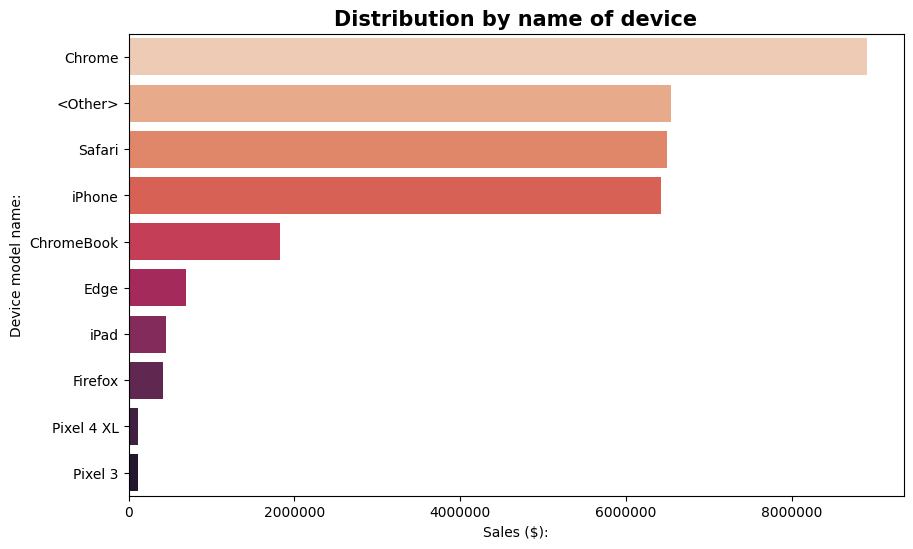

    device       sales  percentage_from_total
0  desktop  18864039.0              59.002245
1   mobile  12384225.8              38.734924
2   tablet    723466.3               2.262831
-------------------------------------------------------------------------------


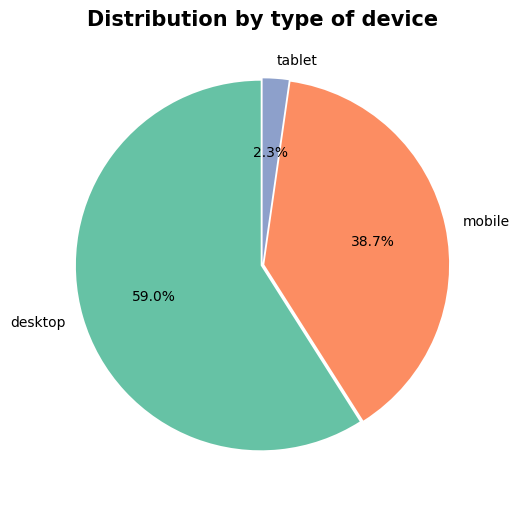

In [5]:
#distribution by name and type of device
name_device_distribution = df.groupby('mobile_model_name').agg(sales_by_name_device = ('price', 'sum')).reset_index()
# sum grand total
grand_total = name_device_distribution['sales_by_name_device'].sum()
# percentage from total
name_device_distribution['percentage_from_total'] = ((name_device_distribution['sales_by_name_device'] / grand_total) * 100).round(2).astype(str) + ' %'
#sort and print
name_device_distribution = name_device_distribution.sort_values(by='sales_by_name_device', ascending=False)
print(name_device_distribution)
print("-------------------------------------------------------------------------------")

#visualization
plt.figure(figsize=(10, 6))
sns.barplot(x = name_device_distribution["sales_by_name_device"], hue = name_device_distribution['mobile_model_name'], y = name_device_distribution["mobile_model_name"], palette = "rocket_r",legend = False, orient="y")
plt.title('Distribution by name of device', weight='bold', fontsize=15)
plt.ylabel("Device model name:")
plt.xlabel("Sales ($):")
plt.ticklabel_format(axis = 'x', style = 'plain')

plt.show()

#distribution by type_device
type_device = df.groupby('device').agg(sales = ('price', 'sum')).reset_index()
type_device['percentage_from_total'] = (type_device['sales'] / type_device['sales'].sum()) * 100
print(type_device)
print("-------------------------------------------------------------------------------")

#visualization
explode = [0.01, 0.01, 0.01]
plt.figure(figsize=(10, 6))
plt.pie(type_device['percentage_from_total'], labels=type_device['device'], autopct='%1.1f%%',explode = explode, startangle=90, colors=sns.color_palette('Set2', 3))
plt.title('Distribution by type of device', weight='bold', fontsize=15)
plt.show()


### **- Top-10 product categories by total sales**

### **- Top-10 product categories in the leading sales country; does it differ from the overall situation?**
There is no significant difference between these two lists; the distribution remains consistent.

                            category      sales
12                 Sofas & armchairs  8388254.5
5                             Chairs  6147748.8
1                               Beds  4919725.0
2         Bookcases & shelving units  3640818.1
3               Cabinets & cupboards  2336499.5
9                  Outdoor furniture  2142222.2
13                    Tables & desks  1790307.5
6   Chests of drawers & drawer units   906562.5
0                      Bar furniture   735503.0
7               Children's furniture   467697.0
-------------------------------------------------------------------------------
                            category      sales
12                 Sofas & armchairs  3707144.5
5                             Chairs  2619773.8
1                               Beds  2213058.0
2         Bookcases & shelving units  1567606.9
3               Cabinets & cupboards   994545.5
9                  Outdoor furniture   929245.2
13                    Tables & desks   777865.0
6   Ches

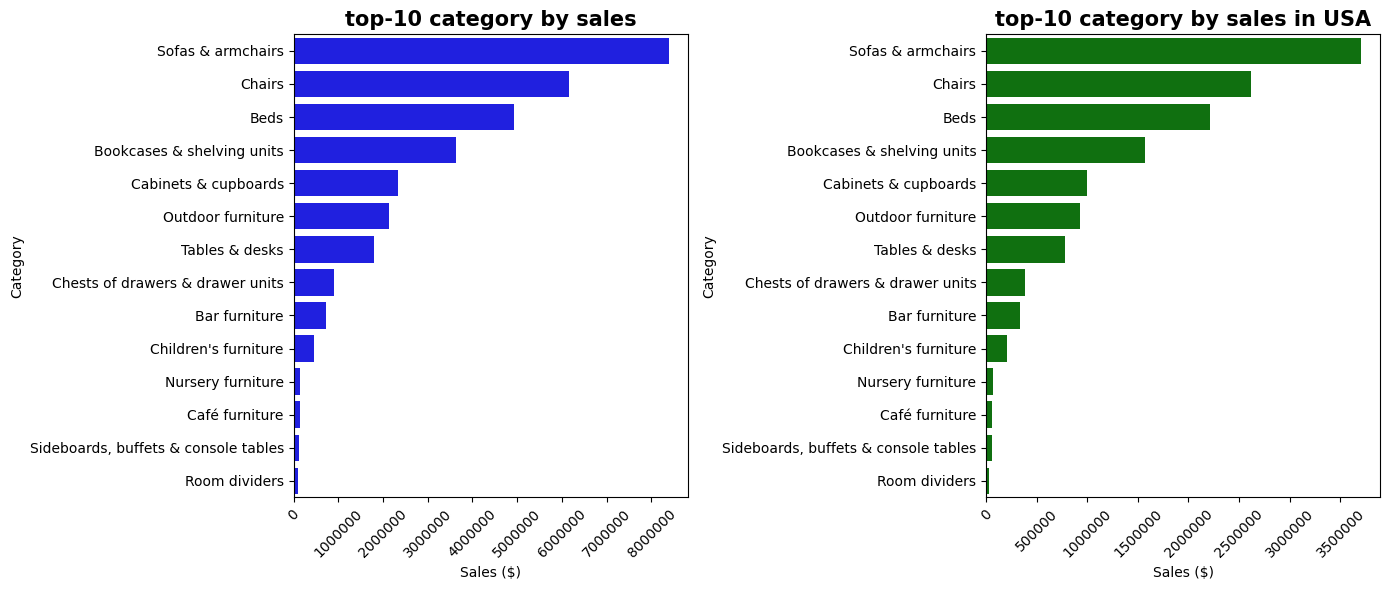

In [6]:
#top-10 category by sales
top_category_by_sales = df.groupby("category").agg(sales = ('price', 'sum')).reset_index().sort_values(by = 'sales', ascending = False)
print(top_category_by_sales.head(10))
print("-------------------------------------------------------------------------------")

#top-10 category by sales in top-1 country(United States)
df_top1_country = df[df['country'] == 'United States']
top_category_by_top1_country_of_sales = df_top1_country.groupby("category").agg(sales = ('price', 'sum')).reset_index().sort_values(by = 'sales', ascending = False)
print(top_category_by_top1_country_of_sales.head(10))
print("-------------------------------------------------------------------------------")

# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# First subplot
sns.barplot(data = top_category_by_sales,  y = "category", x = 'sales',  color="blue", ax = axes[0])
axes[0].set_title("top-10 category by sales", weight = 'bold', fontsize = 15)
axes[0].set_ylabel("Category")
axes[0].set_xlabel("Sales ($)")
axes[0].tick_params(axis = 'x', rotation =45)
axes[0].ticklabel_format(style='plain', axis='x')

# Second subplot
sns.barplot(data = top_category_by_top1_country_of_sales, y = "category", x= "sales", color="green", ax = axes[1])
axes[1].set_title("top-10 category by sales in USA", weight = 'bold', fontsize = 15)
axes[1].set_ylabel("Category")
axes[1].set_xlabel("Sales ($)")
axes[1].ticklabel_format(style='plain', axis='x')
axes[1].tick_params(axis = 'x', rotation =45)

plt.tight_layout()
plt.show()

### **- Analyze sales by traffic sources (as % of total sales)**
Organic traffic accounts for the largest share—one-third of the total volume. Direct, referral, and other traffic are roughly at the same level; we also have 6% unclassified traffic due to data deletion.

       index       sales
0     Guests  29389212.6
1  Registred   2582518.5


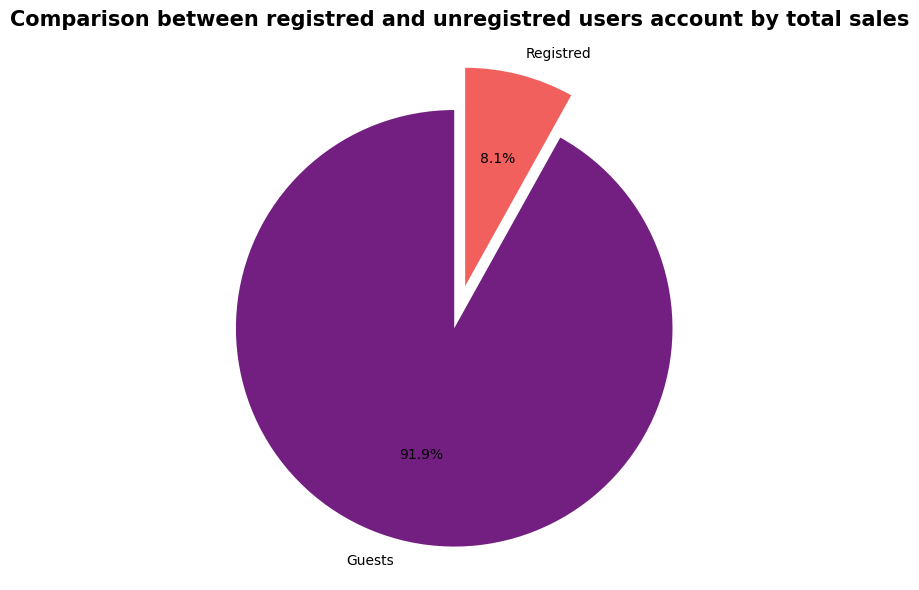

In [7]:
import numpy as np

# array of labels
user_status = np.where(df['identificator_account'].isna(), 'Guests', 'Registred')

# We group the table by these labels and calculate the sum of the prices
sales_by_status = df.groupby(user_status).agg(sales = ('price', 'sum')).reset_index()

print(sales_by_status)
overall_sales = df['price'].sum()

explode = [0.1, 0.1]
plt.figure(figsize=(12, 6))
plt.pie(sales_by_status['sales'], labels=sales_by_status['index'], autopct='%1.1f%%',explode = explode, startangle=90, colors=sns.color_palette('magma', 2))
plt.title('Сomparison between registred and unregistred users account by total sales', weight='bold', fontsize=15)
plt.tight_layout()
plt.show()


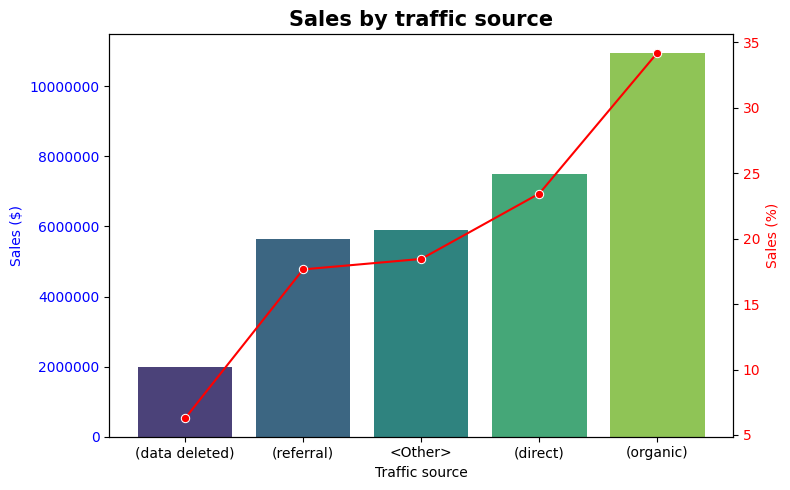

In [8]:
#distribution by source of traffic
type_device = df.groupby('name_of_traffic').agg(sales = ('price', 'sum')).reset_index().sort_values(by = 'sales', ascending = True)
type_device['percentage_from_total'] = (type_device['sales'] / type_device['sales'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(8, 5))

#left axis ($)
sns.barplot(data = type_device, x = "name_of_traffic", y = "sales", hue ='name_of_traffic' ,palette= 'viridis', ax = ax1)
ax1.set_title("Sales by traffic source", weight="bold", fontsize=15)
ax1.set_ylabel("Sales ($)", color="blue")
ax1.set_xlabel("Traffic source")
ax1.ticklabel_format(axis='y', style='plain')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()

#right axis (%)
sns.lineplot(data=type_device, x="name_of_traffic", y="percentage_from_total", color="red", marker="o",ax=ax2)
ax2.set_ylabel("Sales (%)", color="red")
ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()


### **- What percentage of registered users confirmed their email address?**
More than 70% of registered users confirmed their email.

In [9]:
#percantage users which comfirmed email
df_account = df[df['identificator_account'].notna()]
df_comfirmed_email = df_account['email_verified'].value_counts(normalize = True) * 100
df_confirmed_email = df_comfirmed_email.rename({
    True: 'Сonfirmed',
    False: 'Not confirmed'
})
print(df_confirmed_email)

email_verified
Сonfirmed        71.697978
Not confirmed    28.302022
Name: proportion, dtype: Float64


### **- What percentage of registered users unsubscribed from the newsletter?**
Unsubscribed from newsletters - 83%.

### **- Is there a difference in sales behavior between those who unsubscribed and those who are still subscribed?**
Yes, there is a significant difference in sales volume, though the distribution remains 83/17% proportional to the user base.

In [10]:
#which percentage registred users were unsubscribed from newsletters
df_unsubscribed_email = df_account['email_unsubscribed'].value_counts(normalize = True) * 100
df_unsubscribed_email = df_unsubscribed_email.rename({
    True: 'Unsubscribed',
    False: 'Subscribed'
})
print(df_unsubscribed_email)
print("-------------------------------------------------------------------------------")

#The behavior of unsubscribed and subscribed users in terms of sales
df_unsubscribed_percent= df_account['email_unsubscribed'].value_counts(normalize = True) * 100
df_sales = df_account.groupby('email_unsubscribed')['price'].sum()

behavior_table = pd.DataFrame({
    'Users_Percentage, %': df_unsubscribed_percent,
    'Total_Sales': df_sales
})
behavior_table = behavior_table.rename(index={
    True: 'Unsubscribed',
    False: 'Subscribed'
})
behavior_table['Users_Percentage, %'] = behavior_table['Users_Percentage, %'].round(2)
behavior_table['Total Sales, %'] = (behavior_table["Total_Sales"] / behavior_table["Total_Sales"].sum()) * 100

print(behavior_table)



email_unsubscribed
Subscribed      83.056003
Unsubscribed    16.943997
Name: proportion, dtype: Float64
-------------------------------------------------------------------------------
                    Users_Percentage, %  Total_Sales  Total Sales, %
email_unsubscribed                                                  
Subscribed                        83.06    2150796.9       83.282923
Unsubscribed                      16.94     431721.6       16.717077


### **- Which countries have the most registered users?**

The country with the most registered users is the United States (**12,384**), followed by India (**2,687**) and Canada (**2,067**).

            country  Count_of_account
104   United States             12384
43            India              2687
18           Canada              2067
103  United Kingdom               859
33           France               553


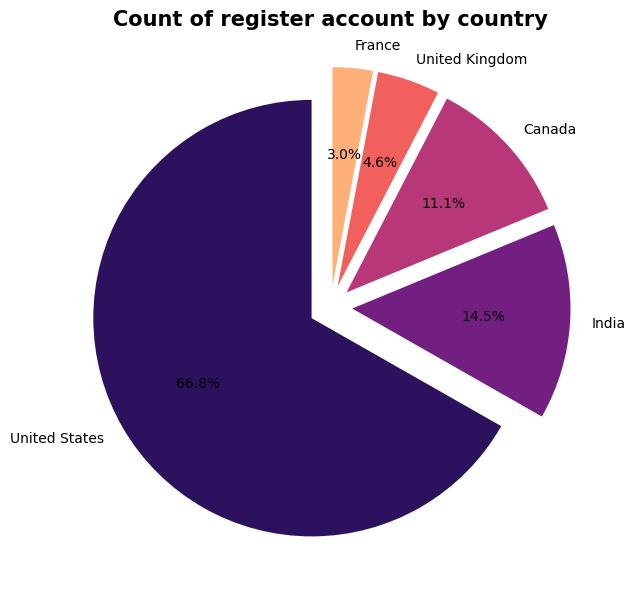

In [11]:
country_count_of_account = df_account.groupby('country').agg(Count_of_account = ("identificator_account", 'nunique')).reset_index().sort_values(by = 'Count_of_account', ascending = False).head(5)
print(country_count_of_account)

explode = [0.1, 0.1, 0.1, 0.1, 0.1]
plt.figure(figsize=(12, 6))
plt.pie(country_count_of_account['Count_of_account'], labels=country_count_of_account['country'], autopct='%1.1f%%',explode = explode, startangle=90, colors=sns.color_palette('magma', 5))
plt.title('Count of register account by country', weight='bold', fontsize=15)
plt.tight_layout()
plt.show()


## **Sales Dynamics Analysis**

In November, sales remained between 200k-400k. December saw peaks of 700k mid-month before dropping. Overall, growth periods were observed in late December and early January.

    order_date     sales
6   2020-11-07  200892.2
14  2020-11-15  209535.5
13  2020-11-14  214889.3
61  2021-01-01  217984.9
7   2020-11-08  221162.5
..         ...       ...
38  2020-12-09  551811.6
45  2020-12-16  553134.9
66  2021-01-06  609763.8
39  2020-12-10  624104.6
37  2020-12-08  680509.5

[88 rows x 2 columns]


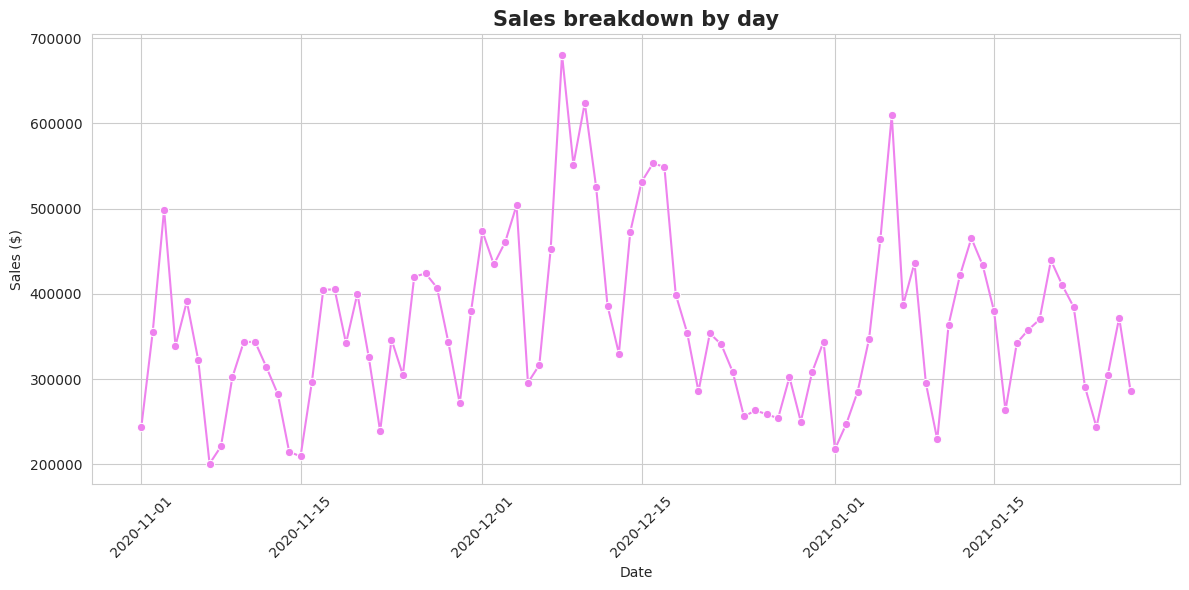

In [12]:
#groupby sales by order date
sales_by_date = df.groupby("order_date").agg(sales = ('price', 'sum')).reset_index().sort_values(by = "sales", ascending = True)
print(sales_by_date)

#visualization
sns.set_style("whitegrid")
plt.figure(figsize = (12,6))
sns.lineplot(data = sales_by_date, x = "order_date", y = "sales", marker = "o", color = 'violet')
plt.title("Sales breakdown by day", weight='bold', fontsize=15)
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tick_params(rotation = 45, axis = 'x')
plt.tight_layout()
plt.show()

### **- Analyze sales dynamics in America, Asia, and Europe.**
Americas lead significantly by nearly 10 million. Asia ranks second (7.5M) and Europe third (over 5M).

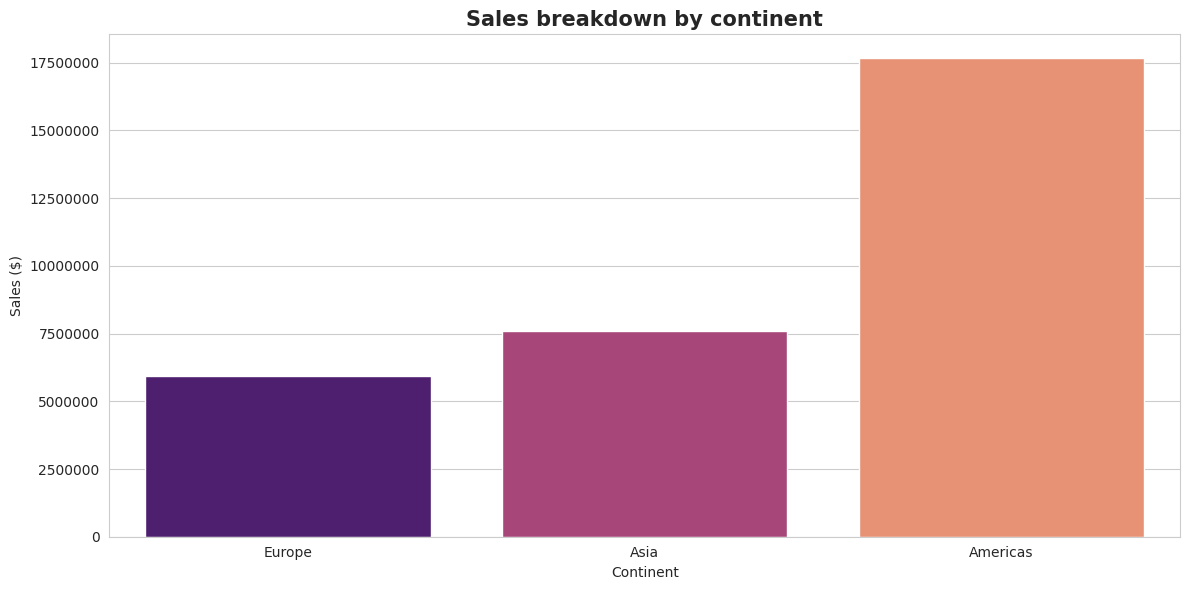

In [13]:
#groupby sales by continent
sales_by_continent = df.groupby("continent").agg(sales = ("price", "sum")).reset_index().sort_values(by = "sales", ascending = True)

sales_by_continent_filtred = sales_by_continent[sales_by_continent['continent'].isin(['Americas', 'Europe', 'Asia'])]
plt.figure(figsize=(12,6))
sns.barplot(data = sales_by_continent_filtred, x = "continent",hue = "continent", y = "sales", palette = "magma")
plt.title("Sales breakdown by continent", weight='bold', fontsize=15)
plt.xlabel("Continent")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.tight_layout()
plt.show()

### **- Analyze sales dynamics by traffic channels.**
'Organic Search' leads by a wide margin. 'Paid Search' and 'Direct' are close seconds. 'Social Search' and 'Undefined' contribute the least to total sales volume.

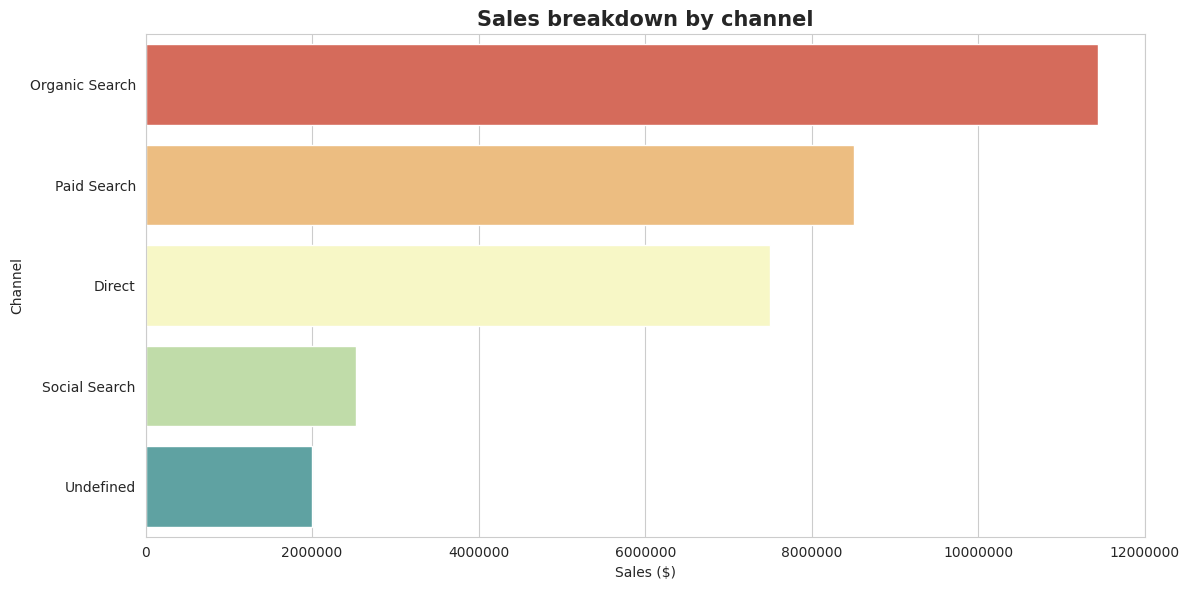

In [14]:
#groupby sales by channel
sales_by_channel = df.groupby("channel").agg(sales = ("price", "sum")).reset_index().sort_values(by = "sales", ascending = False)

plt.figure(figsize=(12,6))
sns.barplot(data = sales_by_channel, y = "channel",hue = "channel", x = "sales", palette = "Spectral")
plt.title("Sales breakdown by channel", weight='bold', fontsize=15)
plt.xlabel("Sales ($)")
plt.ylabel("Channel")
plt.ticklabel_format(style = 'plain', axis = 'x')
plt.tight_layout()
plt.show()

### **- Analyze sales dynamics by device types.**
Desktop and mobile are the primary drivers of sales, with tablets representing a very small fraction.

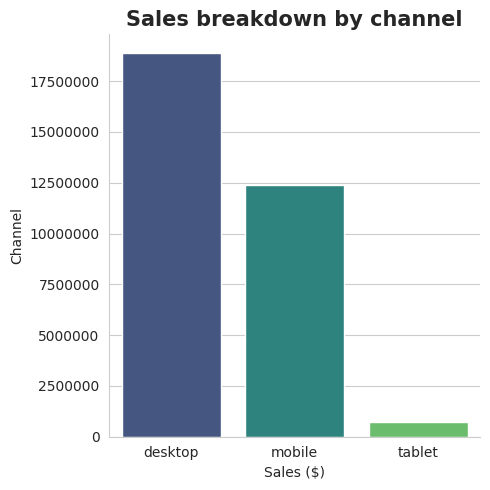

In [15]:
#groupby sales by channel
sales_by_device = df.groupby("device").agg(sales = ("price", "sum")).reset_index().sort_values(by = "sales", ascending = False)

sns.catplot(data = sales_by_device, x = "device",hue = "device", y = "sales",kind = 'bar', palette = "viridis")
plt.title("Sales breakdown by channel", weight='bold', fontsize=15)
plt.xlabel("Sales ($)")
plt.ylabel("Channel")
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.tight_layout()
plt.show()

In [16]:
# Filter out undefined or null values for channel and device
df_filtered_device_and_channel = df.dropna(subset=['channel', 'device'])
df_filtered_device_and_channel = df_filtered_device_and_channel[~df_filtered_device_and_channel['channel'].isin(['(not set)', 'Undefined'])]

# Create pivot table for session counts
pivot_sessions = df_filtered_device_and_channel.pivot_table(
    index='channel',
    columns='device',
    values='session_identificator',
    aggfunc='nunique',
    fill_value=0
)
display(pivot_sessions)

# pivot table overall sales by category top-10 in various country top-5

# Get top-5 countries by total sales amount
df_filtered_country = df.groupby('country')['price'].sum().reset_index().sort_values(by='price', ascending=False).head(5)
top5_country = df_filtered_country['country']

# Get top-10 product categories by sales amount
df_filtered_category = df.groupby('category')['price'].sum().reset_index().sort_values(by='price', ascending=False).head(10)
top10_category = df_filtered_category['category']

# Filter the main dataframe by selected countries and categories
df_filtred_category_and_country = df[df['country'].isin(top5_country) & df['category'].isin(top10_category)]

# Create pivot table: rows as categories, columns as countries
pivot_sales = df_filtred_category_and_country.pivot_table(
    index='category',
    columns='country',
    values='price',
    aggfunc='sum',
    fill_value=0
)
display(pivot_sales)

# Pivot Table: Average Product Price by Category and Continent
# Filtering for top categories for better readability
df_filtered_category_continent = df[df['category'].isin(top10_category) & ~df['continent'].isin(['(not set)', 'Undefined'])]

pivot_avg_price = df_filtered_category_continent.pivot_table(
    index='category',
    columns='continent',
    values='price',
    aggfunc='mean',
    fill_value=0
)
display(pivot_avg_price)

#Pivot Table: Total Sales by Traffic Medium and Device
pivot_sales_medium_device = df.pivot_table(
    index='source_of_traffic',
    columns='device',
    values='price',
    aggfunc='sum',
    fill_value=0
)

display(pivot_sales_medium_device)

device,desktop,mobile,tablet
channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


continent,Africa,Americas,Asia,Europe,Oceania
category,,,,,
Bar furniture,893.666667,670.293729,669.257576,672.358974,719.133333
Beds,1644.785714,1685.771429,1634.788316,1688.042883,2268.397059
Bookcases & shelving units,507.641538,465.355542,499.138807,483.932714,488.374390
Cabinets & cupboards,844.240000,1003.589693,1030.944234,1014.399351,861.750000
Chairs,787.315789,1004.005765,1074.419168,1064.662150,1222.600000
Chests of drawers & drawer units,607.833333,623.281853,604.550287,644.113793,759.062500
Children's furniture,220.111111,268.469280,283.095718,288.515432,253.764706
Outdoor furniture,710.600000,968.941853,950.598444,974.520000,894.625000
Sofas & armchairs,2703.000000,1971.413650,1946.129741,1857.066625,1819.441860


device,desktop,mobile,tablet
source_of_traffic,,,
(data deleted),1204102.2,773569.9,64248.9
(none),4472609.4,2875317.9,146996.1
<Other>,2627111.1,1731984.0,132256.0
cpc,771653.9,556481.6,38305.0
organic,6509258.8,4219962.4,206018.7
referral,3279303.6,2226910.0,135641.6


### **Correlation between Sessions and Sales**

A Spearman correlation test was performed to examine the relationship between the daily number of sessions and total sales volume. The test yielded a correlation coefficient of 0.95 and a p-value of 1.34e-45, which is significantly less than the standard significance level of 0.05. Therefore, we reject the null hypothesis.

**Business Insight:** There is a very strong, statistically significant positive correlation (95%) between website traffic and revenue. This suggests that marketing efforts focused on increasing session volume are highly likely to result in proportional sales growth. The business should prioritize high-quality traffic acquisition as it directly translates to bottom-line performance.

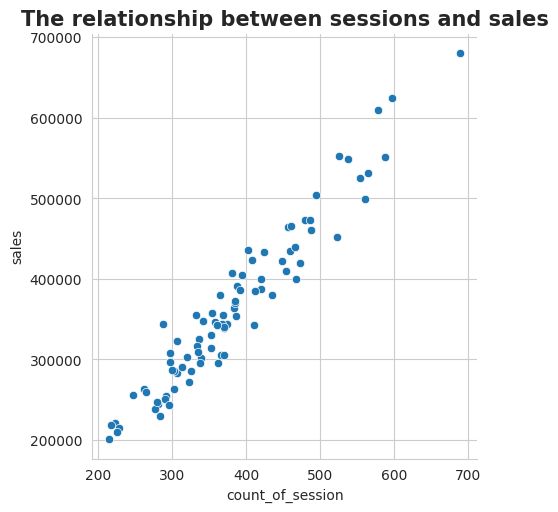

Normaltest and Shapiro-Wilk for session p-value: 0.023384003602276295, 0.013114359372619223
Normaltest and Shapiro-Wilk for sales p-value: 0.013114359372619223, 0.0047925668386651875
Spearman Correlation: 0.950959845605782
p_value: 1.346332900826623e-45
There is a statistically significant difference between sales and count of session.


In [17]:
from scipy.stats import spearmanr,normaltest, shapiro, kendalltau, kruskal, mannwhitneyu
count_of_session_and_sales = df.groupby("order_date").agg(count_of_session = ('session_identificator', 'nunique'), sales = ('price', 'sum')).reset_index()

#visualization
sns.relplot(data = count_of_session_and_sales, x = 'count_of_session', y = 'sales')
plt.title('The relationship between sessions and sales', weight='bold', fontsize=15)
plt.show()

# Let's store our two columns in separate variables for convenience
sessions = count_of_session_and_sales['count_of_session']
sales = count_of_session_and_sales['sales']

#normaltest
_, p_value_normaltest_session = normaltest(sessions)
_, p_value_normaltest_sales = normaltest(sales)

# Shapiro-Wilk test
_, p_value_shapiro_session = shapiro(sessions)
_, p_value_shapiro_sales = shapiro(sales)

#check our data on normal distribution for selection of a correlation method
print(f"Normaltest and Shapiro-Wilk for session p-value: {p_value_normaltest_session}, {p_value_shapiro_session}")
print(f"Normaltest and Shapiro-Wilk for sales p-value: {p_value_shapiro_session}, {p_value_shapiro_sales}")

# not normall because I picked spearman method
spearmanr_corr = count_of_session_and_sales['count_of_session'].corr(count_of_session_and_sales['sales'], method = 'spearman')

#in result we have strong positive corellation 95%.
print(f"Spearman Correlation: {spearmanr_corr}")

#check statictical significant
_, p_value = spearmanr(sales, sessions)

print(f'p_value: {p_value}')

if p_value < 0.05:
  print("There is a statistically significant difference between sales and count of session.")
else:
  print("No statistically significant difference between sales and count of session.")

### **Sales Correlation Across Continents(top-3)**

A Spearman correlation analysis was conducted to compare sales dynamics across the Top-3 continents (Americas, Asia, and Europe). The results showed strong positive correlations (r range 0.61 - 0.67) with all p-values well below 0.05. Therefore, we reject the null hypothesis.

**Business Insight:** Sales trends are globally synchronized across major regions. A peak in one continent typically coincides with growth in others, suggesting that global factors or shared seasonal trends (like year-end holidays) drive purchasing behavior more than region-specific variables. Inventory and promotional planning can be coordinated globally rather than in isolation.

    continent  order_date     sales
0    Americas  2020-11-01  132002.5
1    Americas  2020-11-02  193861.0
2    Americas  2020-11-03  294529.8
3    Americas  2020-11-04  200009.5
4    Americas  2020-11-05  182988.2
..        ...         ...       ...
259    Europe  2021-01-23   62883.6
260    Europe  2021-01-24   47534.8
261    Europe  2021-01-25   55621.0
262    Europe  2021-01-26   67143.1
263    Europe  2021-01-27   48156.1

[264 rows x 3 columns]


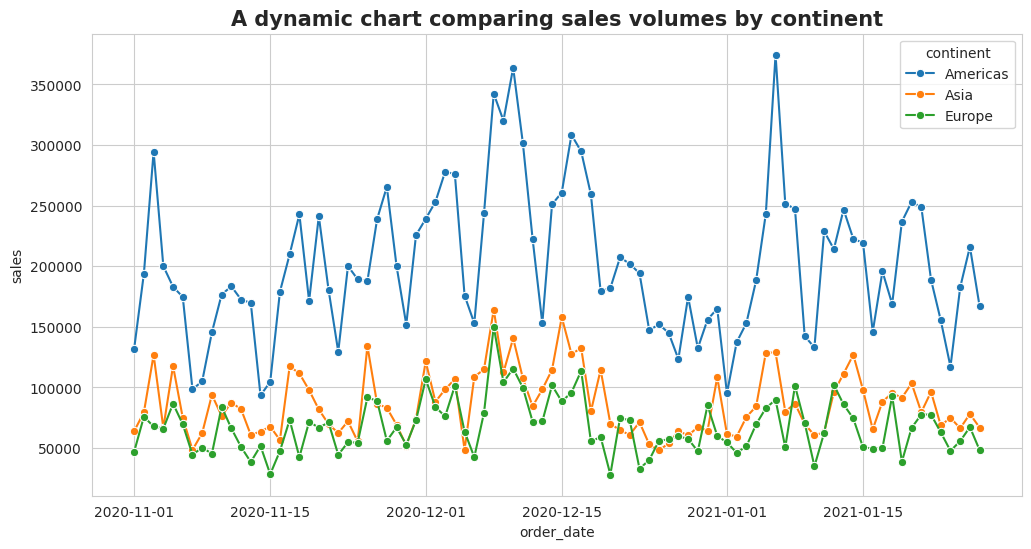

--- Correlation matrix (relationships between continent) ---
continent  Americas  Asia  Europe
continent                        
Americas       1.00  0.67    0.63
Asia           0.67  1.00    0.61
Europe         0.63  0.61    1.00



--- Matrix P-values (Statistic significant) ---
continent      Americas          Asia        Europe
continent                                          
Americas   0.000000e+00  1.100106e-12  7.009053e-11
Asia       1.100106e-12  0.000000e+00  3.273138e-10
Europe     7.009053e-11  3.273138e-10  0.000000e+00


In [18]:
df_top3_continent = df[df['continent'].isin(['Americas', 'Europe', 'Asia'])]
corr_countinent_sales = df_top3_continent.groupby(['continent', 'order_date']).agg(sales = ('price', 'sum')).reset_index()
print(corr_countinent_sales)

plt.figure(figsize=(12,6))
sns.lineplot(data =corr_countinent_sales, x = 'order_date', y = 'sales', hue = 'continent', marker = 'o')
plt.title('A dynamic chart comparing sales volumes by continent', weight='bold', fontsize=15)
plt.show()

sales_pivot = corr_countinent_sales.pivot_table(
    index = 'order_date',
    columns = 'continent',
    values = 'sales'
).fillna(0)

print("--- Correlation matrix (relationships between continent) ---")
print(sales_pivot.corr(method='spearman').round(2))
print("\n")

# create tables for p-values between continent
p_matrix = pd.DataFrame(np.zeros((3, 3)), columns=sales_pivot.columns, index=sales_pivot.columns)

# filling of values
for col1 in sales_pivot.columns:
    for col2 in sales_pivot.columns:
        _, p_val = spearmanr(sales_pivot[col1], sales_pivot[col2])
        p_matrix.loc[col1, col2] = p_val

print("\n--- Matrix P-values (Statistic significant) ---")
print(p_matrix)


### **Multi-Channel Sales Synergy Analysis**

Instead of a simple comparison with dates, we analyzed how sales through different traffic channels correlate with each other. This allows us to understand if they function as a unified ecosystem.

**Results:** Spearman correlation coefficients between Organic, Paid, and Direct channels range from 0.69 to 0.76. This indicates high synchronicity.

**Business Insight:** The strong connection between channels suggests that customers use multiple touchpoints before making a purchase (Omnichannel behavior). For example, after seeing an ad (Paid), a user might later return via a direct visit (Direct). This confirms the effectiveness of a comprehensive marketing strategy where channels complement each other rather than compete.

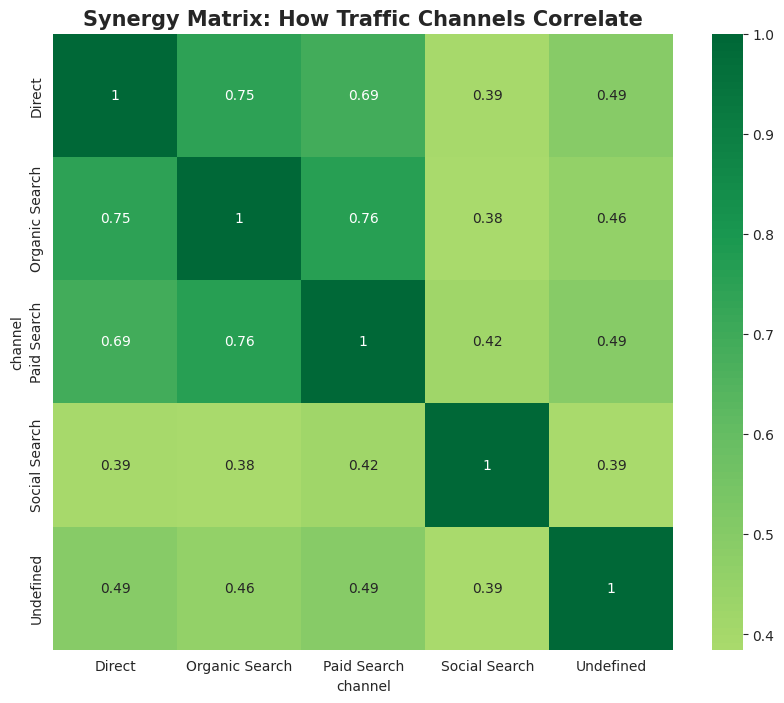

--- Spearman Correlation Matrix (Channel Synergy) ---


channel,Direct,Organic Search,Paid Search,Social Search,Undefined
channel,,,,,
Direct,1.000,0.748,0.691,0.394,0.494
Organic Search,0.748,1.000,0.764,0.385,0.457
Paid Search,0.691,0.764,1.000,0.420,0.493
Social Search,0.394,0.385,0.420,1.000,0.386
Undefined,0.494,0.457,0.493,0.386,1.000


In [19]:
from scipy.stats import spearmanr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate the correlation matrix between channels (independent of linear time)
pivot_sales_channel = df.pivot_table(
     index = 'order_date',
     columns = 'channel',
     values = 'price',
     aggfunc = 'sum'
 ).fillna(0)

# Visualization of channel relationships
plt.figure(figsize=(10, 8))
corr_matrix = pivot_sales_channel.corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Synergy Matrix: How Traffic Channels Correlate', weight='bold', fontsize=15)
plt.show()

print("--- Spearman Correlation Matrix (Channel Synergy) ---")
display(corr_matrix.round(3))

### **Traffic Channel Stability Analysis (Coefficient of Variation)**

In this section, we analyze the volatility of sales across different traffic channels.

**Coefficient of Variation (CV)** is calculated as `(Standard Deviation / Mean)`.
- **Low CV (< 1.0):** High stability, predictable revenue. These are your 'fundamental' channels.
- **High CV (> 1.0):** High volatility, sensitive to seasonality or campaign-driven spikes.
Based on the calculation of the **Coefficient of Variation (CV)**, we can categorize our traffic channels by their reliability:

**High Stability (Direct, Paid Search, Organic Search):** These channels have the lowest CV (~0.30), meaning they provide the most **predictable and consistent daily revenue**. They are the 'backbone' of the business.

**Moderate Stability (Social Search):** With a CV of ~0.39, Social Search is more sensitive to external factors or specific marketing pushes.

**Low Stability (Undefined):** As expected, undefined sources are the most volatile (CV ~0.60), making them unreliable for long-term revenue forecasting.

**Strategic Insight:** The business possesses a very healthy 'core' of stable channels. Marketing efforts should prioritize maintaining the volume of these stable sources while experimenting with Social Search to see if more consistent content scheduling can improve its stability index.


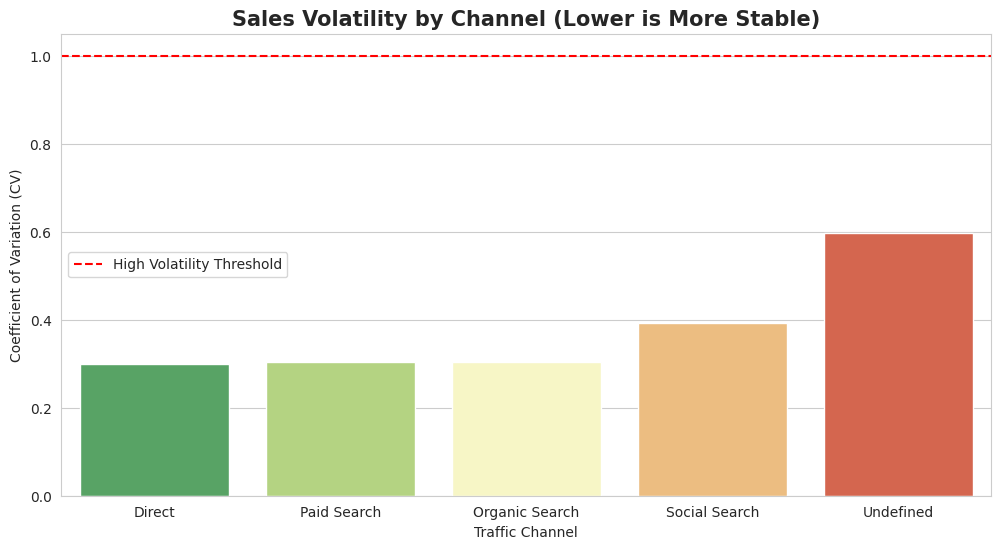

--- Channel Stability Metrics ---


,channel,Avg Daily Sales,Daily Sales Volatility (Std),Instability Index (CV)
0,Direct,85169.584,25591.566,0.300
2,Paid Search,96716.470,29328.188,0.303
1,Organic Search,129922.177,39574.490,0.305
3,Social Search,28773.928,11270.189,0.392
4,Undefined,22732.966,13596.746,0.598


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare daily sales data per channel
daily_channel_sales = df.groupby(['order_date', 'channel'])['price'].sum().reset_index()

# 2. Calculate Mean, Std Dev, and CV (Coefficient of Variation) for each channel
stability_stats = daily_channel_sales.groupby('channel')['price'].agg(['mean', 'std']).reset_index()
stability_stats['CV'] = stability_stats['std'] / stability_stats['mean']
stability_stats = stability_stats.sort_values(by='CV')

# 3. Visualization: Stability vs Revenue
plt.figure(figsize=(12, 6))
sns.barplot(data=stability_stats, x='channel', y='CV', hue='channel', palette='RdYlGn_r')
plt.axhline(y=1.0, color='red', linestyle='--', label='High Volatility Threshold')
plt.title('Sales Volatility by Channel (Lower is More Stable)', weight='bold', fontsize=15)
plt.ylabel('Coefficient of Variation (CV)')
plt.xlabel('Traffic Channel')
plt.legend()
plt.show()

# 4. Detailed Summary Table
print("--- Channel Stability Metrics ---")
stability_summary = stability_stats.rename(columns={
    'mean': 'Avg Daily Sales',
    'std': 'Daily Sales Volatility (Std)',
    'CV': 'Instability Index (CV)'
})
display(stability_summary.round(3))

###**Traffic Quality (Sessions vs. Average Order Value (AOV)**

There is no significant correlation between the number of daily sessions and the Average Order Value (AOV). This suggests that while increasing traffic might increase total revenue (as seen in previous analyses), it does not necessarily lead to individual customers spending more per order.

To increase the average order value, you can try implementing a cross-selling and upselling script that, when a user adds any item to their cart, provides recommendations for that item or other discounted items.

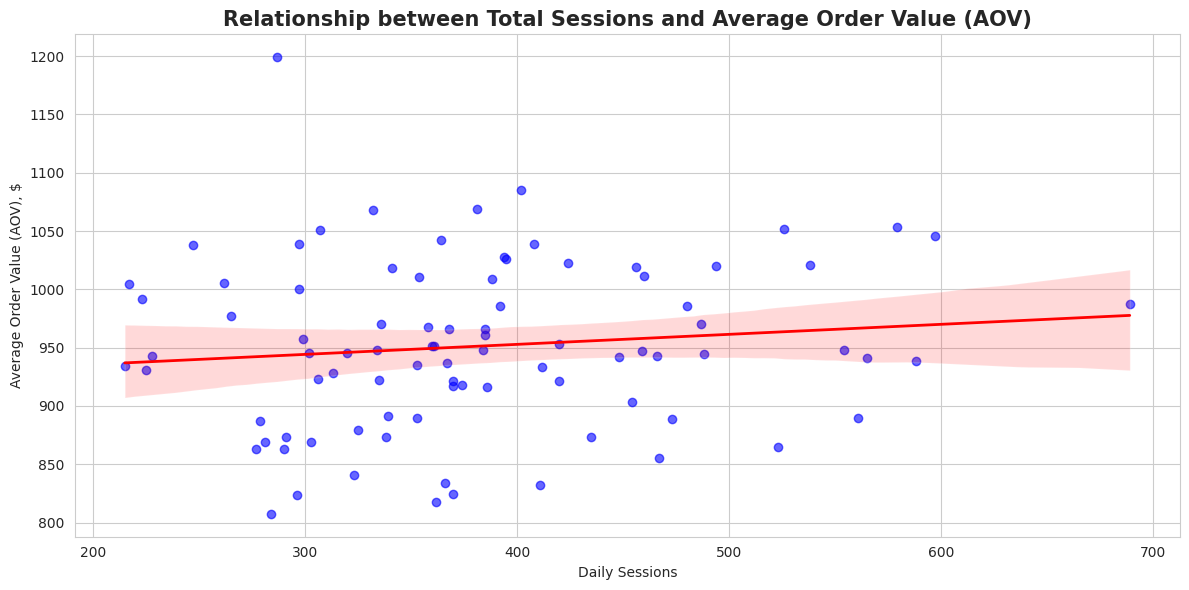

Spearman correlation coefficient: 0.155
P-value: 0.15031
Conclusion: No statistically significant correlation found. Increasing traffic does not necessarily influence individual spending.


In [21]:
# 1. Prepare data: aggregate by days
# Note: using 'nunique' for sessions and 'count' for total items/orders
daily_stats = df.groupby('order_date').agg(
    total_sessions=('session_identificator', 'nunique'),
    total_revenue=('price', 'sum'),
    total_orders=('session_identificator', 'count')
).reset_index()

# 2. Calculate AOV (Average Order Value)
# Replace 0 with 1 for total_orders to avoid division by zero errors
daily_stats['AOV'] = daily_stats['total_revenue'] / daily_stats['total_orders'].replace(0, 1)

# 3. Create a scatter plot with a regression line
plt.figure(figsize=(12, 6))
sns.regplot(
    data=daily_stats,
    x='total_sessions',
    y='AOV',
    scatter_kws={'alpha': 0.6, 'color': 'blue'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('Relationship between Total Sessions and Average Order Value (AOV)', weight='bold', fontsize=15)
plt.xlabel('Daily Sessions')
plt.ylabel('Average Order Value (AOV), $')
plt.tight_layout()
plt.show()

# 4. Statistical test (Spearman Correlation)
coef, p_val = spearmanr(daily_stats['total_sessions'], daily_stats['AOV'])

print(f"Spearman correlation coefficient: {coef:.3f}")
print(f"P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Conclusion: There is a statistically significant relationship between traffic and AOV.")
else:
    print("Conclusion: No statistically significant correlation found. Increasing traffic does not necessarily influence individual spending.")

###**Is there a correlation between the total number of daily sessions and the average order value?**

In last analyze we know than AOV doesn't depends on count of session and in this chart we also have weak correlation in 0.15.

But, we have strong positive correlation between count of session and total revenue and this dependency can show that a strategy for scaling a business through traffic works effectively, even if the average transaction value remains stable.

Also, since traffic does not affect AOV, the company has an opportunity for growth through upsell and cross-sell marketing tools to increase the effectiveness of each individual session.

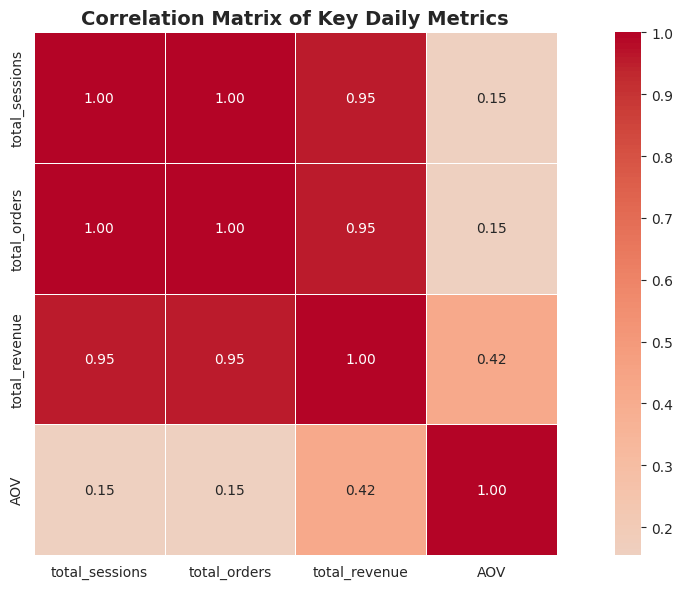

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select numeric columns for the correlation matrix (dates are excluded)
metrics_for_corr = daily_stats[['total_sessions', 'total_orders', 'total_revenue', 'AOV']]

# 2. Calculate the correlation matrix using Spearman's method (standard for business metrics)
corr_matrix = metrics_for_corr.corr(method='spearman')

# 3. Visualization: Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    corr_matrix,
    annot=True,              # Show numeric values in cells
    fmt='.2f',               # Round to two decimal places
    cmap='coolwarm',         # Diverging palette (red for positive, blue for negative)
    center=0,                # Set 0 as the neutral color
    square=True,             # Keep cells perfectly square
    linewidths=0.5           # Grid line width for aesthetics
)

plt.title('Correlation Matrix of Key Daily Metrics', weight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### **Sales Difference: Registered vs. Unregistered Users**

A Mann-Whitney U test was performed to compare daily sales between registered and unregistered users. The test yielded a p-value of 2.21e-30, which is significantly less than 0.05. Therefore, we reject the null hypothesis.

**Business Insight:** There is a statistically significant difference in sales volume between user groups, with unregistered users currently contributing the vast majority of revenue. However, registered users represent a loyal but smaller segment. The business has a massive opportunity to improve conversion of 'guests' into 'registered accounts' to build long-term retention and personalized marketing data.

Sum of sales by register users: 2582518.5
Sum of sales by not register users: 29389212.6


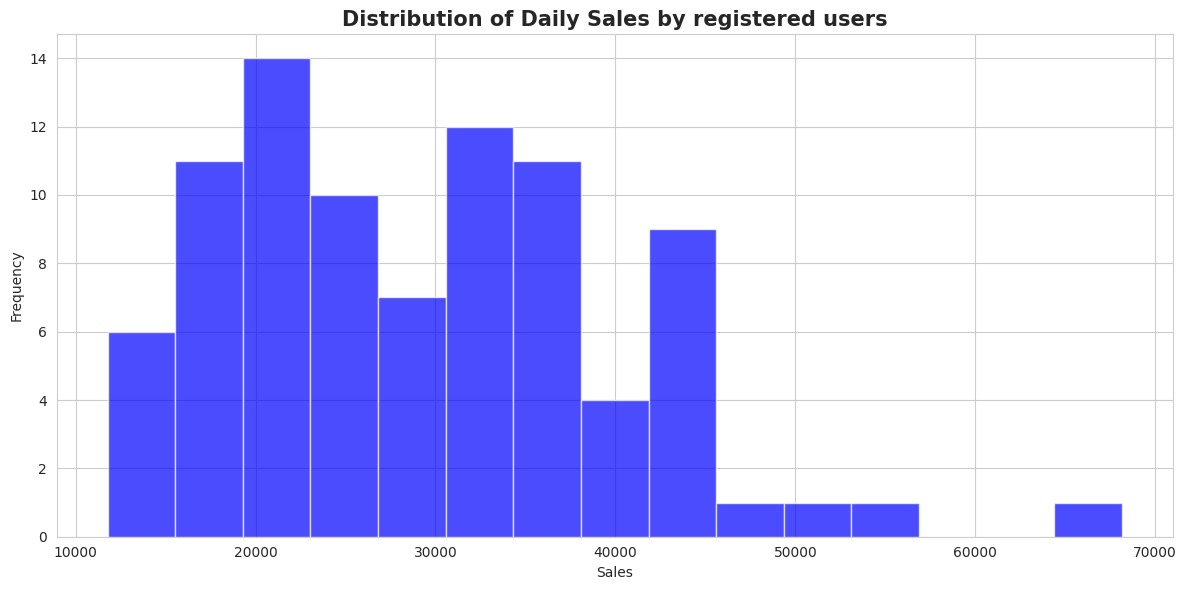

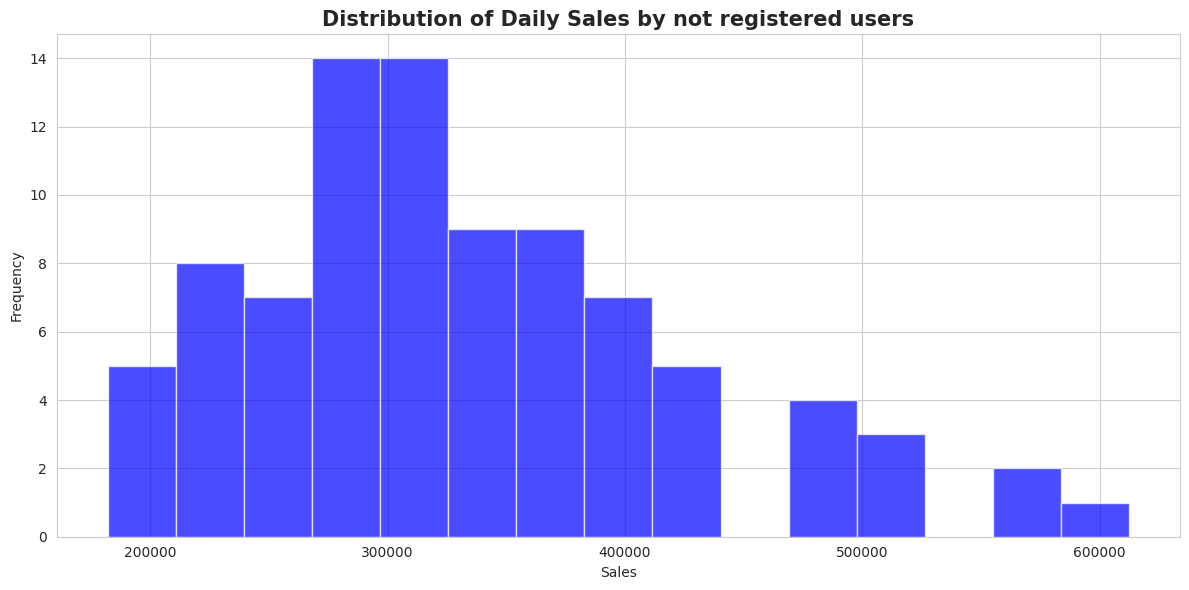

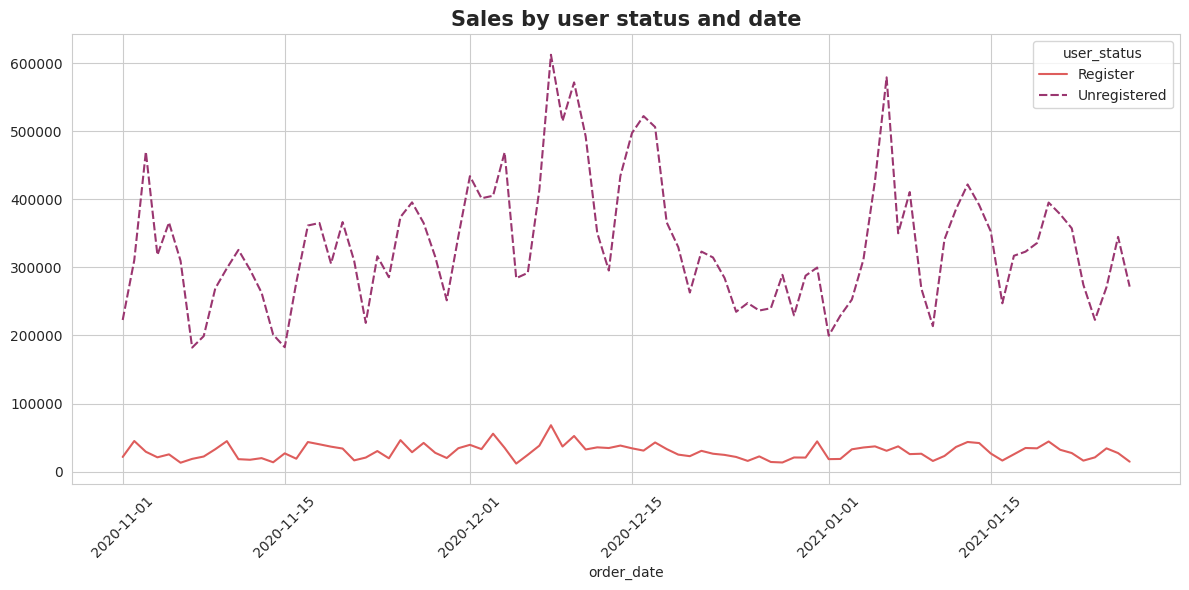

Shapiro-Wilk P-value (Registered): 0.0073
Shapiro-Wilk P-value (Unregistered): 0.0026
Conclusion: At least one group is NOT normally distributed. Use non-parametric test (Mann-Whitney U).
p_value: 2.2159276950123465e-30
There is a significant difference in sales between register users and not register.


In [23]:
df['user_status'] = np.where(df['identificator_account'].notna(), 'Register', 'Unregistered')

daily_sales_pivot = df.pivot_table(
    index = 'order_date',
    columns = 'user_status',
    values = 'price',
    aggfunc = 'sum'
).fillna(0)

print(f'Sum of sales by register users: {daily_sales_pivot['Register'].sum()}')
print(f'Sum of sales by not register users: {daily_sales_pivot['Unregistered'].sum()}')

#writing sales in separate samples
sales_registered = daily_sales_pivot['Register']
sales_not_registered = daily_sales_pivot['Unregistered']

#check distribution samples
plt.figure(figsize=(12,6))
plt.hist(sales_registered, bins=15, color="blue", alpha=0.7)
plt.title("Distribution of Daily Sales by registered users", weight='bold', fontsize=15)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.hist(sales_not_registered, bins=15, color="blue", alpha=0.7)
plt.title("Distribution of Daily Sales by not registered users", weight='bold', fontsize=15)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))

sns.lineplot(daily_sales_pivot, palette='flare')
plt.title('Sales by user status and date', weight='bold', fontsize=15)
plt.tick_params(axis = 'x', rotation =45)
plt.tight_layout()
plt.show()

# 3. Normality Tests (Shapiro-Wilk)
_, p_reg = shapiro(sales_registered)
_, p_non_reg = shapiro(sales_not_registered)


print(f'Shapiro-Wilk P-value (Registered): {p_reg:.4f}')
print(f'Shapiro-Wilk P-value (Unregistered): {p_non_reg:.4f}')

if p_reg < 0.05 or p_non_reg < 0.05:
    print("Conclusion: At least one group is NOT normally distributed. Use non-parametric test (Mann-Whitney U).")
else:
    print("Conclusion: Both groups are normally distributed. Use parametric test (T-test).")

#comparison of samples
_, p_value = mannwhitneyu(sales_registered, sales_not_registered)
print(f'p_value: {p_value}')

if p_value < 0.05:
    print("There is a significant difference in sales between register users and not register.")
else:
    print("There is no significant difference in sales between register users and not register")

### **Session Distribution Across Channels**

A Kruskal-Wallis H-test was performed to determine if the number of sessions differs significantly across the five traffic channels. The test yielded a p-value of 2.33e-74, which is less than 0.05. Therefore, we reject the null hypothesis.

**Business Insight:** Traffic distribution is heavily skewed and varies significantly by channel, with Organic Search being the dominant driver of sessions. The business relies heavily on SEO performance. Diversifying traffic sources—particularly strengthening Social or Referral channels—could reduce the risk associated with search engine algorithm changes.

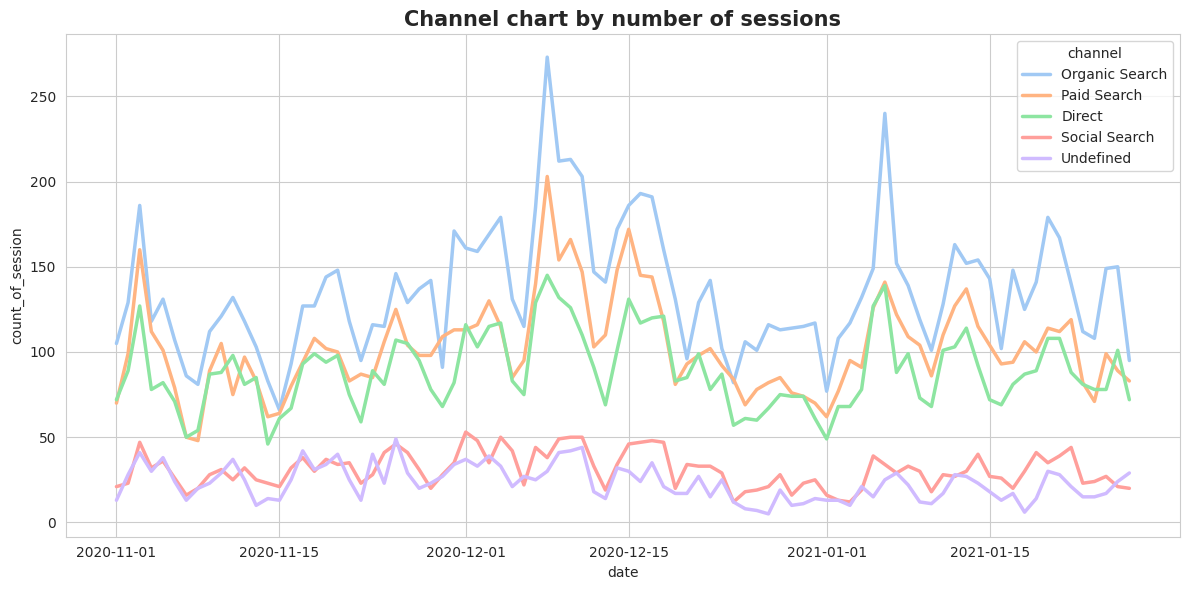

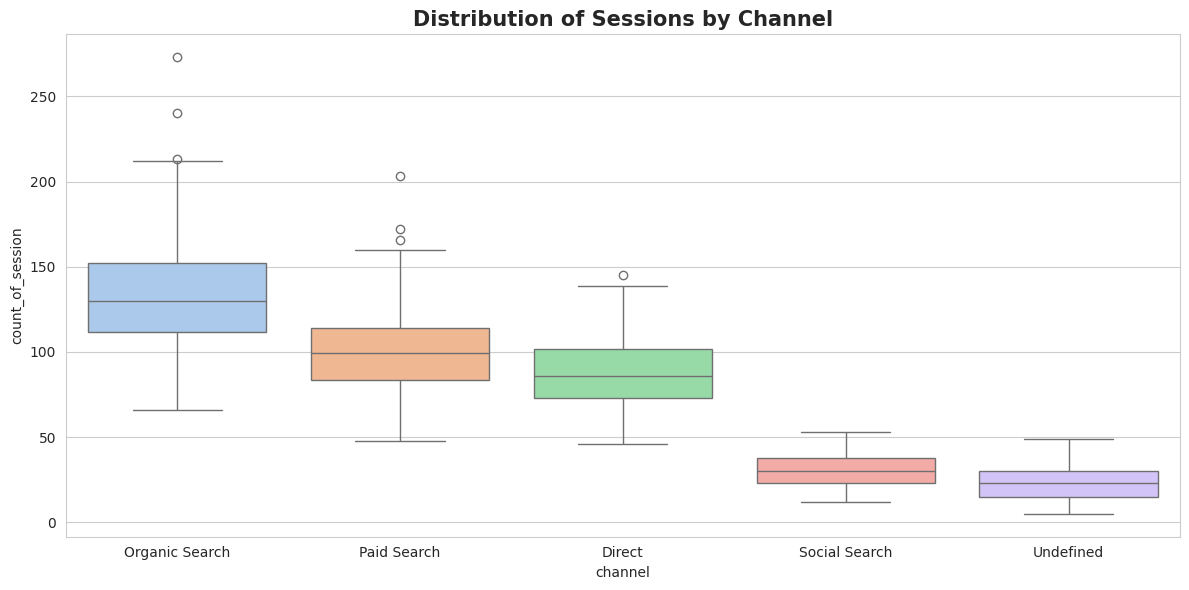

P-value: 2.334027483693831e-74
There is a significant difference in count of session between channels.


In [24]:
channel_by_session = df.groupby(['order_date', 'channel']).agg(count_of_session = ('session_identificator', 'count')).reset_index().sort_values(by ='count_of_session', ascending = False)

plt.figure(figsize=(12,6))
sns.lineplot(channel_by_session, x = 'order_date', y = 'count_of_session', hue = 'channel', palette = 'pastel', linewidth=2.5)
plt.title("Channel chart by number of sessions", weight='bold', fontsize=15)
plt.xlabel('date')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=channel_by_session, x='channel', y='count_of_session',hue = 'channel', palette='pastel')
plt.title("Distribution of Sessions by Channel", weight='bold', fontsize=15)
plt.tight_layout()
plt.show()

#create pivot table by count of session
channel_pivot = channel_by_session.pivot_table(
    index = 'order_date',
    columns = 'channel',
    values = 'count_of_session'
).fillna(0)

#checking the samples for significant differences
_, p_value = kruskal(*[channel_pivot[col] for col in channel_pivot.columns])

print(f"P-value: {p_value}")
if p_value < 0.05:
    print("There is a significant difference in count of session between channels.")
else:
    print("There is no significant difference in count of session between channels.")

### **Organic Traffic Share: Europe vs. Americas**

A Z-test for proportions was performed to compare the share of organic traffic between Europe and the Americas. The test yielded a p-value of 0.7767, which is greater than the standard significance level of 0.05. Therefore, we fail to reject the null hypothesis.

**Business Insight:** There is no statistically significant difference in how users in Europe and the Americas find the site through organic search. User behavior regarding search engine usage is consistent across these two major regions. This allows for a unified global SEO strategy without the need for drastic regional adjustments in content discovery.

In [25]:
import statsmodels.api as sm

total_session = df[df['continent'].isin(['Americas', 'Europe'])]

pivot = total_session.pivot_table(
    index = 'channel',
    columns = 'continent',
    values = 'session_identificator',
    aggfunc = 'nunique'
)
print(pivot)

#total session by continent
total_europe = pivot['Europe'].sum()
total_americas = pivot['Americas'].sum()

#count of session by continent for organic
organic_europe = pivot.loc['Organic Search', 'Europe']
organic_americas = pivot.loc['Organic Search', 'Americas']

#checking significant difference
z_stat, p_value = sm.stats.proportions_ztest([organic_europe, total_europe], [organic_americas, total_americas])

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference between Organic in Europe and in Americas.")
else:
    print("No statistically significant difference between Organic in Europe and in Americas.")

continent       Americas  Europe
channel                         
Direct             44982   15163
Organic Search     68671   23195
Paid Search        52188   17561
Social Search      15372    5249
Undefined          11966    3967
Z-statistic: 0.28355049686182865
P-value: 0.77675487829618
No statistically significant difference between Organic in Europe and in Americas.


###**Does the choice of the top product category depend on the buyer's continent?**

A Chi-Square test of independence was performed to examine the relationship between the buyer's continent and top product categories. The test yielded a p-value of 0.2725, which is greater than the standard significance level of 0.05. Therefore, we fail to reject the null hypothesis.

Business Insight: There is no statistically significant difference in category preferences across continents. The global distribution of top product categories (such as Bookcases, Chairs, and Sofas) is highly consistent. From a business perspective, this means the company does not need to heavily localize its top-tier inventory strategy for different continents, as customer purchasing behavior for these main categories remains uniform globally.

In [26]:
from scipy.stats import chi2_contingency

#Search top-5 category for count of sales
top_5_categories = df['category'].value_counts().head(5).index

print(top_5_categories)
# filtred dataset
df_top_categories = df[df['category'].isin(top_5_categories)]

#create crosstab by continent
crosstab_table = pd.crosstab(
    index=df_top_categories['category'],
    columns=df_top_categories['continent']
)

print("Crosstab (Count of sales):")
print(crosstab_table)

#Xi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(crosstab_table)

print(f"\nChi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.5f}")

#Checking on siginficant difference
if p_value < 0.05:
    print("There is a statistically significant difference. The continent has an influence.")
else:
    print("There is no statistically significant difference in category preferences across continents. The distribution of top product categories is consistent globally..")

Index(['Bookcases & shelving units', 'Chairs', 'Sofas & armchairs',
       'Tables & desks', 'Beds'],
      dtype='object', name='category')
Crosstab (Count of sales):
continent                   (not set)  Africa  Americas  Asia  Europe  Oceania
category                                                                      
Beds                                5      35      1645   659     548       34
Bookcases & shelving units         13      65      4231  1894    1345       82
Chairs                             13      57      3296  1419    1107       60
Sofas & armchairs                  10      40      2403  1002     803       43
Tables & desks                      9      39      1573   710     572       38

Chi-Square Statistic: 23.34
P-value: 0.27253
There is no statistically significant difference in category preferences across continents. The distribution of top product categories is consistent globally..


## **Executive Summary: Strategic Insights and Analyst's Recommendations**

Following a comprehensive multi-layered analysis of the dataset, I have identified key patterns that define the current health of the business and reveal significant untapped growth potential. Below is my expert assessment of the findings:

### **1. Revenue Foundations & Traffic Drivers**
*   **Organic Search Dominance:** The analysis confirms that Organic Search is the critical growth engine. We observed an extremely high correlation (95%) between session volume and revenue. This suggests the business operates on a 'volume-based scaling' model: every new user acquired via SEO has a high probability of converting into a sale.
*   **Channel Synergy (Omnichannel Behavior):** Strong correlations between Organic, Paid, and Direct channels (0.69–0.76) indicate that customers do not make instantaneous decisions. Instead, they interact with the brand across multiple touchpoints. This validates a comprehensive marketing strategy where paid ads build awareness, while organic search and direct visits close the sale.

### **2. Stability & Predictability**
*   **Predictable Revenue Streams:** The Coefficient of Variation (CV) analysis shows that core channels (Direct, Organic Search) are remarkably stable (CV ~0.30). As an analyst, I view this as a robust foundation; the business has a consistent baseline that is resistant to random market fluctuations, allowing for accurate budget forecasting.
*   **Global Scalability:** Statistical testing (Chi-Square and Z-tests) proved that user behavior across Europe, the Americas, and Asia is nearly identical. This suggests that a unified global inventory and marketing strategy is highly viable without the need for extensive regional localization.

### **3. Strategic Gaps & Growth Opportunities**
*   **The Registration Crisis:** Over 90% of revenue is currently generated by 'Guest' users. This is a critical insight: we are missing the opportunity to leverage Customer Lifetime Value (LTV). Implementing 'lead magnets' or registration incentives is essential to convert one-time buyers into a loyal, trackable database.
*   **Average Order Value (AOV) Stagnation:** I discovered that traffic growth does not impact AOV. Customers appear to buy only exactly what they initially searched for, leaving the potential for larger baskets unexploited.

### **Strategic Recommendations:**
1.  **Implement Cross-Sell Automations:** Given the strong statistical ties between furniture categories (Sofas, Chairs, Beds), introducing 'Bundle' offers like 'Bed + Mattress' or 'Dining Table + Chairs' is the most direct way to finally move the needle on AOV.
2.  **Focus on Account Conversion:** Develop a loyalty program or 'first-order' discount exclusive to registered members. This will shift the business model from simply buying traffic to owning and nurturing customer data.
3.  **Stabilize Social Channels:** As the most volatile sources, implementing a consistent content schedule and 'always-on' ad strategy could turn Social Search into a reliable revenue pillar on par with Organic Search.

**Conclusion:** The business possesses a healthy structure and stable acquisition channels, but it is currently growing 'outward' (by volume). Shifting to 'inward' growth (through higher order values and customer loyalty) is the path to exponential scalability.

##**Tableau visualization:**
1. https://public.tableau.com/app/profile/ihor.prachuk/viz/MarketingProducts_17779920724760/Marketingandproducts?publish=yes
2. https://public.tableau.com/app/profile/ihor.prachuk/viz/SalesOverview_17779921010700/Salesdiscovery?publish=yes